# 1. Importação dos dados

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import math
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller


In [268]:
base_c_nulos = False

if base_c_nulos:
    PATH_FILE = "../dados/bruto/base_consolidada.csv"
else:
    PATH_FILE = "../dados/tratado/consolidado_sem_nulos.csv"



if base_c_nulos:
    PATH_TO_SAVE = "../resultados/base_c_vazios"
else:
    PATH_TO_SAVE = "../resultados/base_tratada"

In [269]:
df = pd.read_csv(
    PATH_FILE,
    index_col=0
)

# 2. Inspeção inicial

## 2.1 Estrutura

In [270]:
df.shape

(2601, 10)

In [271]:
df.info()

<class 'pandas.DataFrame'>
Index: 2601 entries, 2016-05-02 to 2026-04-30
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Selic        2601 non-null   float64
 1   IPCA         2601 non-null   float64
 2   PIB          2601 non-null   float64
 3   Exportacoes  2601 non-null   float64
 4   Importacoes  2601 non-null   float64
 5   FEDFUNDS     2601 non-null   float64
 6   IBOV         2601 non-null   float64
 7   SP500        2601 non-null   float64
 8   Petroleo     2601 non-null   float64
 9   USD/BRL      2601 non-null   float64
dtypes: float64(10)
memory usage: 223.5+ KB


In [272]:
df_info = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes,
    'Não-Nulos': df.notnull().sum(),
    'Nulos': df.isnull().sum()
}).reset_index(drop=True)

df_info


,Coluna,Tipo,Não-Nulos,Nulos
0,Selic,float64,2601,0
1,IPCA,float64,2601,0
2,PIB,float64,2601,0
3,Exportacoes,float64,2601,0
4,Importacoes,float64,2601,0
5,FEDFUNDS,float64,2601,0
6,IBOV,float64,2601,0
7,SP500,float64,2601,0
8,Petroleo,float64,2601,0
9,USD/BRL,float64,2601,0


In [273]:
df.head()

,Selic,IPCA,PIB,Exportacoes,Importacoes,FEDFUNDS,IBOV,SP500,Petroleo,USD/BRL
2016-05-02,14.25,0.78,516189.8,17471.6,11344.5,0.37,53562.0,2081.429932,44.779999,3.4328
2016-05-03,14.25,0.78,516189.8,17471.6,11344.5,0.37,52260.0,2063.370117,43.650002,3.4965
2016-05-04,14.25,0.78,516189.8,17471.6,11344.5,0.37,52553.0,2051.120117,43.779999,3.5549
2016-05-05,14.25,0.78,516189.8,17471.6,11344.5,0.37,51671.0,2050.629883,44.320000,3.5454
2016-05-06,14.25,0.78,516189.8,17471.6,11344.5,0.37,51718.0,2057.139893,44.660000,3.5331


In [274]:
df.tail()

,Selic,IPCA,PIB,Exportacoes,Importacoes,FEDFUNDS,IBOV,SP500,Petroleo,USD/BRL
2026-04-24,14.75,0.67,1155104.3,34344.8,24596.5,3.64,190745.0,7165.080078,94.400002,5.0308
2026-04-27,14.75,0.67,1155104.3,34344.8,24596.5,3.64,189579.0,7173.910156,96.370003,4.9791
2026-04-28,14.75,0.67,1155104.3,34344.8,24596.5,3.64,188619.0,7138.799805,99.930000,4.9996
2026-04-29,14.75,0.67,1155104.3,34344.8,24596.5,3.64,184750.0,7135.950195,106.879997,4.9943
2026-04-30,14.50,0.67,1155104.3,34344.8,24596.5,3.64,187318.0,7209.009766,105.070000,5.0175


# 3. Qualidade dos Daods

In [275]:
df.isna().sum()

Selic          0
IPCA           0
PIB            0
Exportacoes    0
Importacoes    0
FEDFUNDS       0
IBOV           0
SP500          0
Petroleo       0
USD/BRL        0
dtype: int64

In [276]:
df.isna().mean().mul(100).sort_values(ascending=False)

Selic          0.0
IPCA           0.0
PIB            0.0
Exportacoes    0.0
Importacoes    0.0
FEDFUNDS       0.0
IBOV           0.0
SP500          0.0
Petroleo       0.0
USD/BRL        0.0
dtype: float64

## 3.1 Duplicidades

In [277]:
df.index.duplicated().sum()

np.int64(0)

In [278]:
df.index.min()

'2016-05-02'

In [279]:
df.index.max()

'2026-04-30'

In [280]:
df.index = pd.to_datetime(df.index)

df.index.to_series().diff().value_counts().head()

1 days    2073
3 days     520
2 days       6
5 days       1
Name: count, dtype: int64

In [281]:
ordem = [
    "Selic",
    "IPCA",
    "PIB",
    "Exportacoes",
    "Importacoes",
    "FEDFUNDS",
    "IBOV",
    "SP500",
    "Petroleo",
    "USD/BRL"
]

tabela_nulos = pd.DataFrame({
    "Variável": ordem,
    "Observações": df[ordem].notna().sum(),
    "Ausentes": df[ordem].isna().sum(),
    "% Ausentes": (df[ordem].isna().mean() * 100).round(2)
})

tabela_nulos

,Variável,Observações,Ausentes,% Ausentes
Selic,Selic,2601,0,0.0
IPCA,IPCA,2601,0,0.0
PIB,PIB,2601,0,0.0
Exportacoes,Exportacoes,2601,0,0.0
Importacoes,Importacoes,2601,0,0.0
FEDFUNDS,FEDFUNDS,2601,0,0.0
IBOV,IBOV,2601,0,0.0
SP500,SP500,2601,0,0.0
Petroleo,Petroleo,2601,0,0.0
USD/BRL,USD/BRL,2601,0,0.0


In [282]:
if base_c_nulos:
    tabela_nulos.to_excel(
        f"{PATH_TO_SAVE}/tabelas/diagnostico_nulos.xlsx",
        index=False
    )

# 4.Estatística Descritiva

In [283]:
df.describe().T.apply(lambda s: s.apply('{:.2f}'.format))

,count,mean,std,min,25%,50%,75%,max
Selic,2601.00,9.57,4.21,2.00,6.50,10.50,13.75,15.00
IPCA,2601.00,0.41,0.38,-0.68,0.19,0.35,0.59,1.62
PIB,2601.00,764925.01,191892.71,511062.20,588910.10,734654.40,932675.10,1172242.10
Exportacoes,2601.00,23359.71,5637.27,13663.10,18403.50,22545.50,28946.50,34344.80
Importacoes,2601.00,18914.31,4628.19,11129.70,14491.50,19666.50,22927.50,28182.30
FEDFUNDS,2601.00,2.30,1.89,0.05,0.40,1.83,4.33,5.33
IBOV,2601.00,105462.22,28211.24,48472.00,84886.00,107752.00,122807.00,198657.00
SP500,2601.00,3929.80,1359.89,2000.54,2767.32,3839.50,4668.97,7209.01
Petroleo,2601.00,65.05,17.22,-37.63,52.75,64.40,75.30,123.70
USD/BRL,2601.00,4.64,0.90,3.06,3.78,5.01,5.37,6.30


In [284]:
df.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
Selic,2.000000,2.000000,6.500000,10.500000,13.750000,1.500000e+01,1.500000e+01
IPCA,-0.380000,-0.230000,0.190000,0.350000,0.590000,1.150000e+00,1.350000e+00
PIB,513967.500000,530139.700000,588910.100000,734654.400000,932675.100000,1.084820e+06,1.155104e+06
Exportacoes,14550.500000,15744.200000,18403.500000,22545.500000,28946.500000,3.190110e+04,3.312140e+04
Importacoes,11344.500000,11766.700000,14491.500000,19666.500000,22927.500000,2.599690e+04,2.790460e+04
FEDFUNDS,0.050000,0.080000,0.400000,1.830000,4.330000,5.330000e+00,5.330000e+00
IBOV,50838.000000,60129.000000,84886.000000,107752.000000,122807.000000,1.474290e+05,1.881070e+05
SP500,2084.389893,2181.739990,2767.320068,3839.500000,4668.970215,6.656920e+03,6.941470e+03
Petroleo,23.549999,40.619999,52.750000,64.400002,75.300003,9.504000e+01,1.123400e+02
USD/BRL,3.109700,3.164200,3.775100,5.007600,5.367000,5.720300e+00,6.043100e+00


# 5.Distribuições

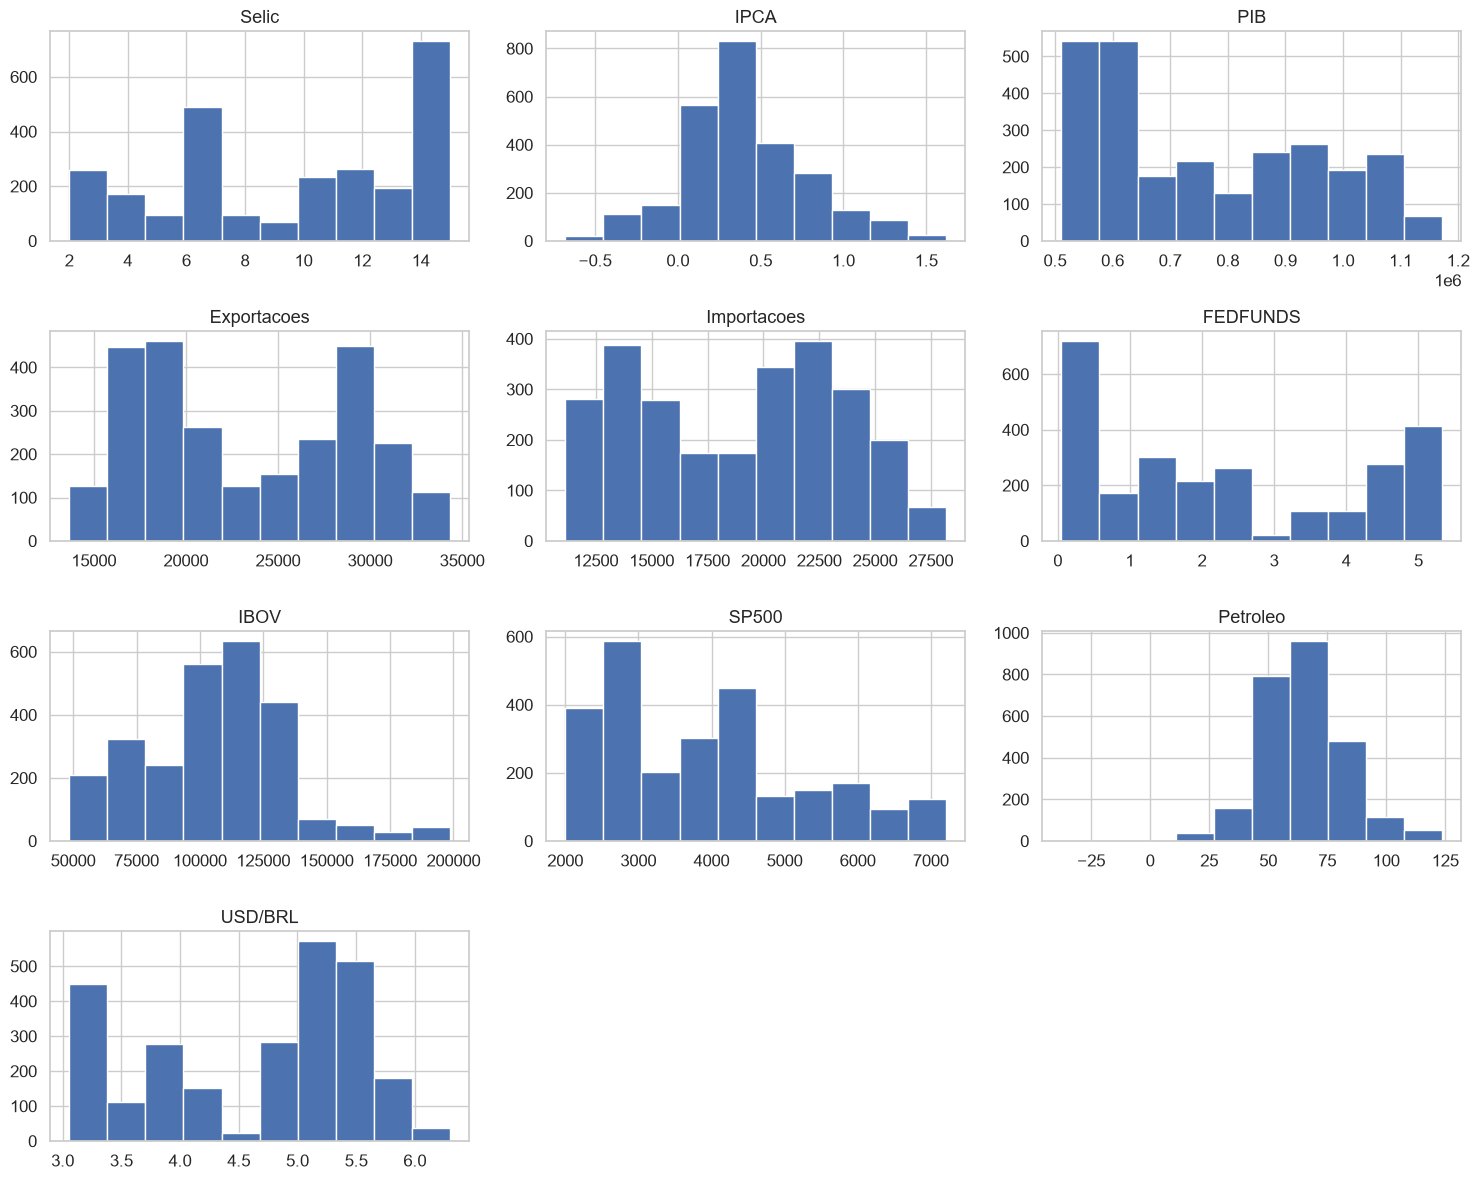

In [285]:
df.hist(
    figsize=(15, 12),
    bins=10
)
plt.tight_layout()
plt.show()

Observe:

- assimetria;
- concentração;
- caudas;
- possíveis distribuições multimodais;
- valores extremos.

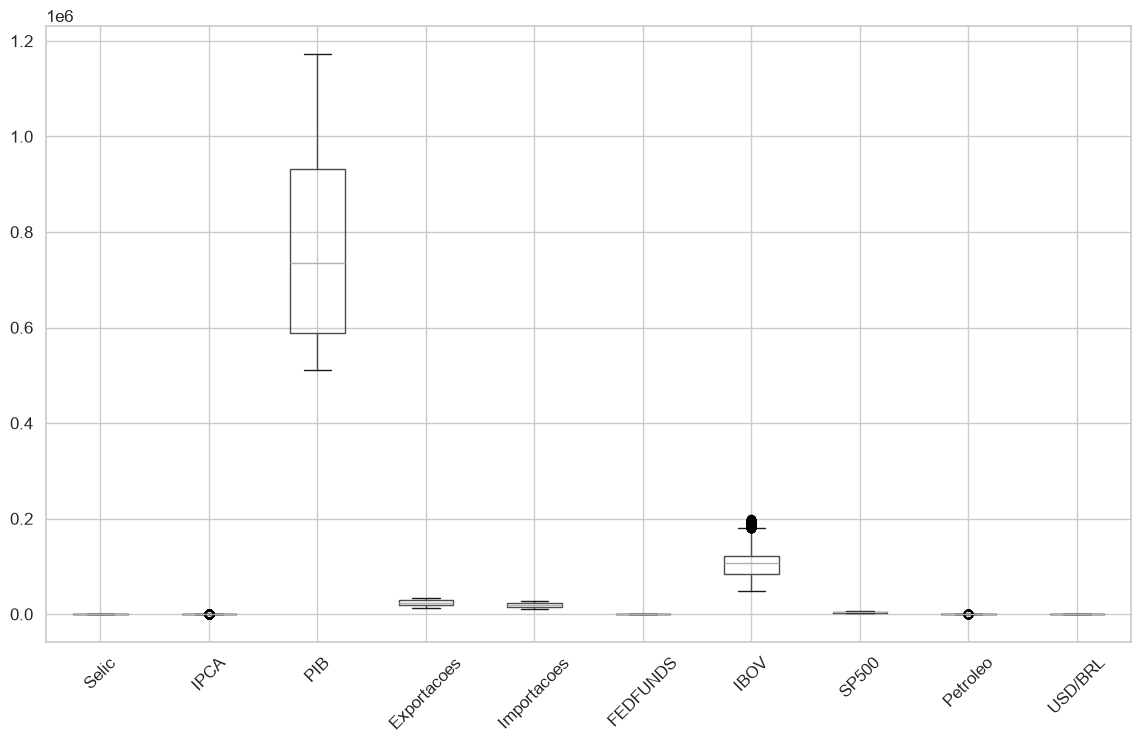

In [286]:
plt.figure(figsize=(14, 8))

df.boxplot()

plt.xticks(rotation=45)
plt.show()

C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3445405423.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3445405423.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3445405423.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3445405423.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_

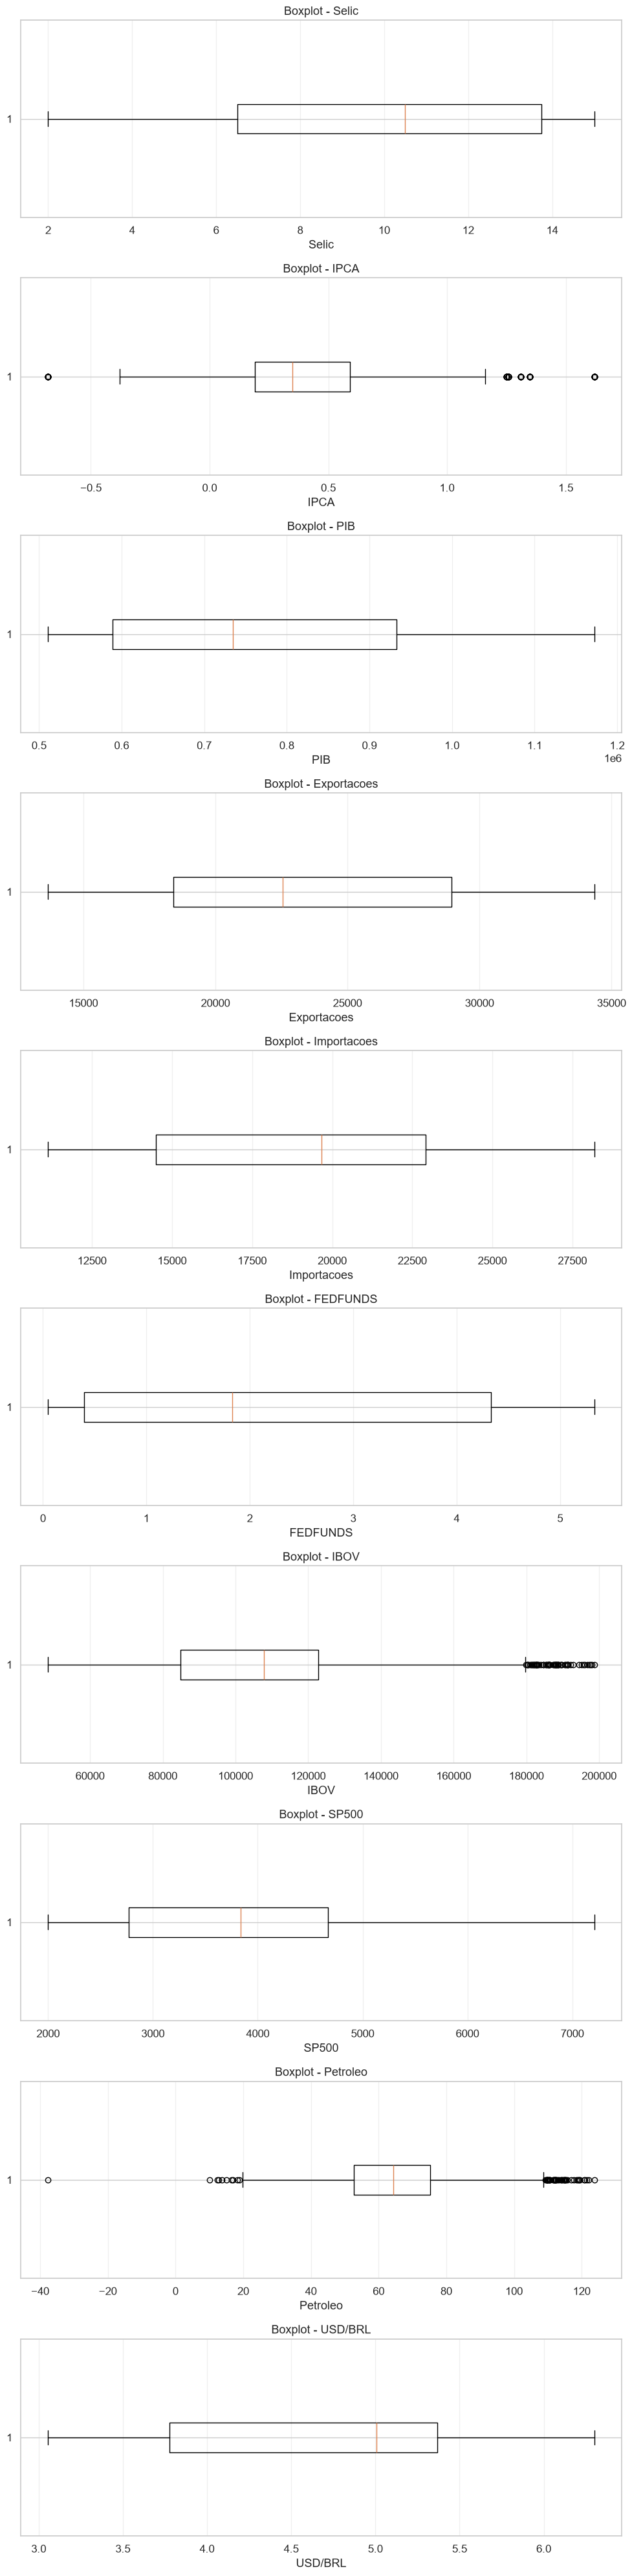

In [287]:


# Seleciona apenas as colunas numéricas
colunas = df.select_dtypes(include="number").columns

# Cria uma figura com um subplot para cada coluna
fig, axes = plt.subplots(
    nrows=len(colunas),
    ncols=1,
    figsize=(10, 4 * len(colunas))
)

# Caso exista apenas uma coluna
if len(colunas) == 1:
    axes = [axes]

for ax, coluna in zip(axes, colunas):
    ax.boxplot(
        df[coluna].dropna(),
        vert=False
    )
    
    ax.set_title(f"Boxplot - {coluna}")
    ax.set_xlabel(coluna)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3473854627.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3473854627.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3473854627.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\3473854627.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\gnlin\AppData\Local\Temp\ipykernel_

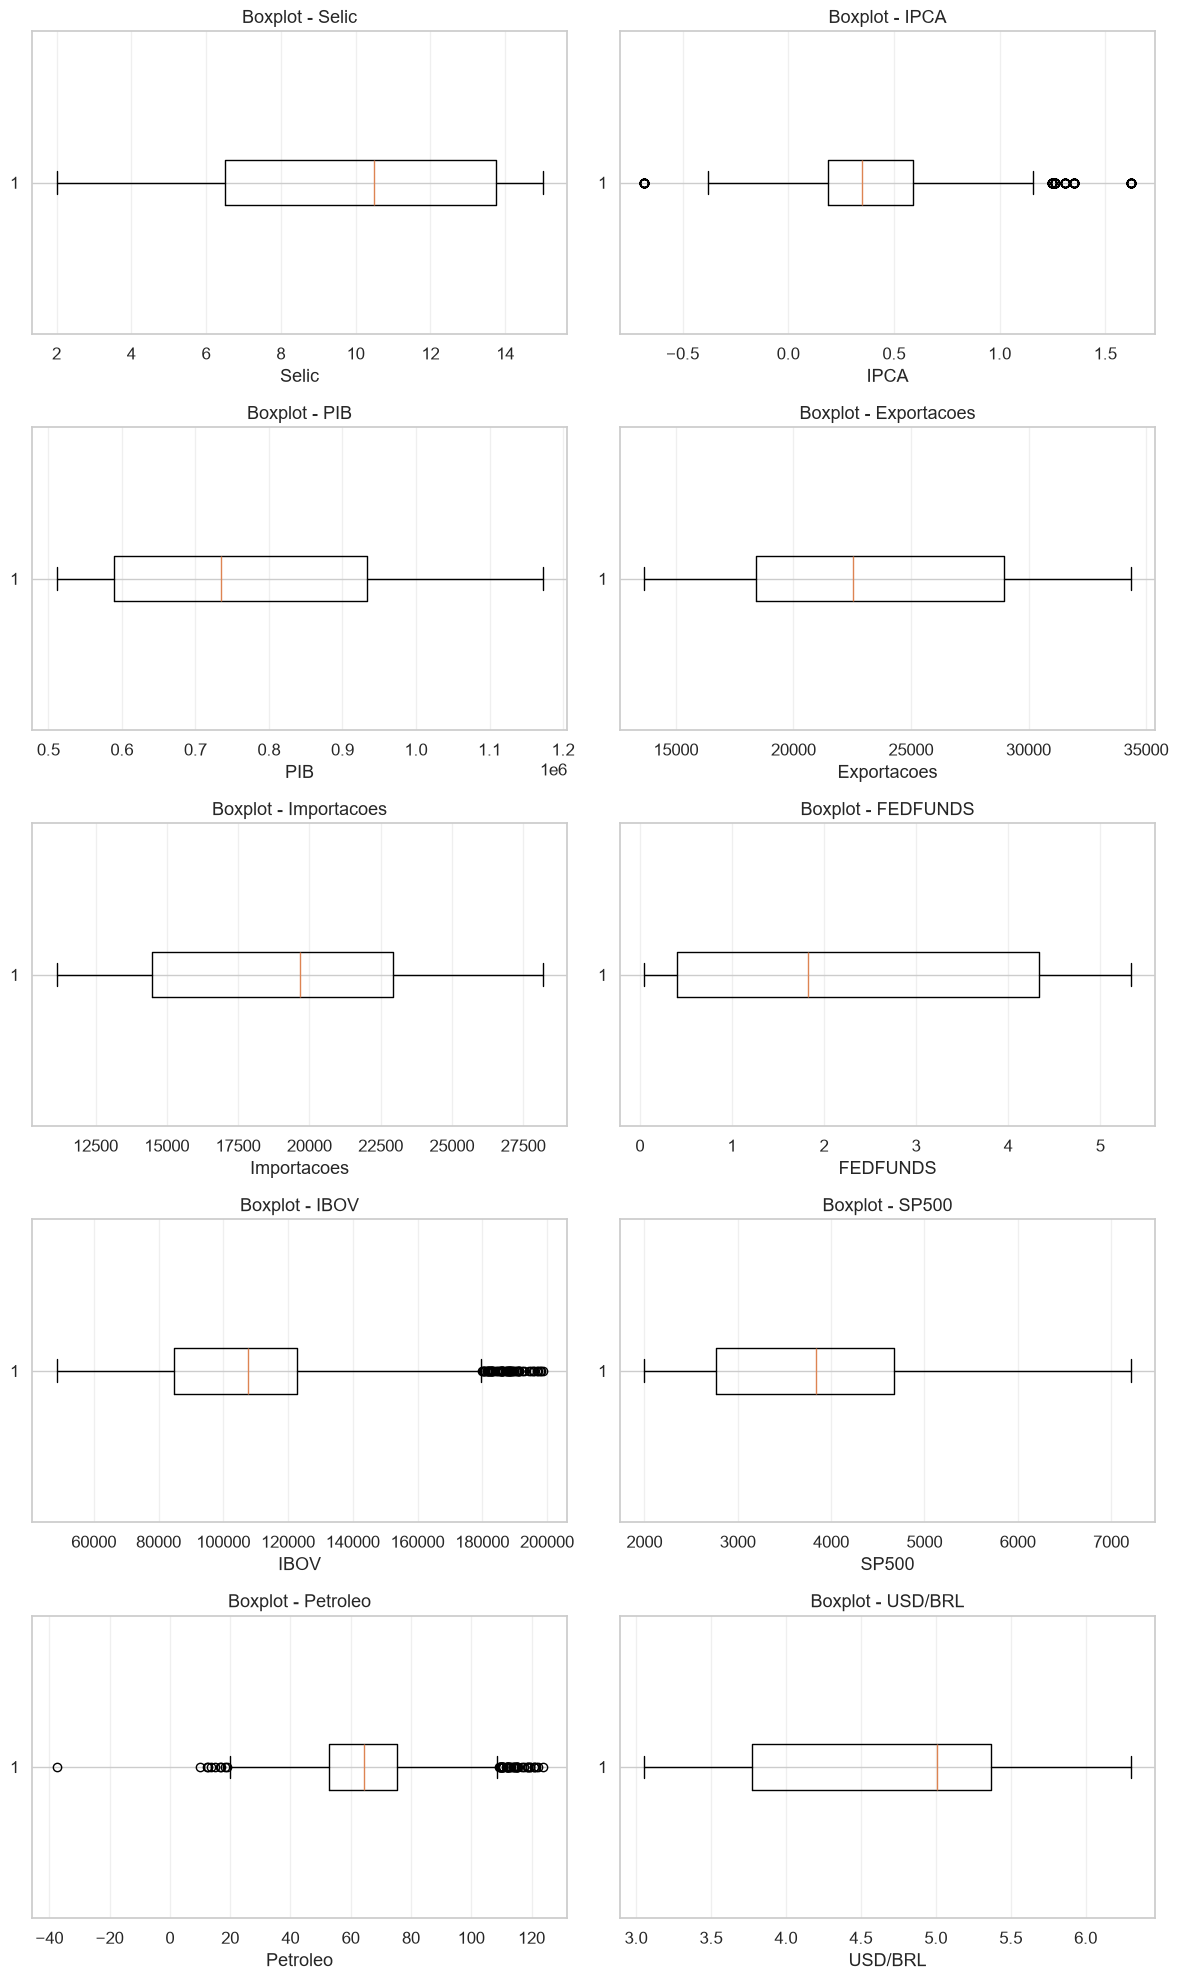

In [288]:
colunas = df.select_dtypes(include="number").columns

n = len(colunas)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12, 4 * nrows)
)

axes = axes.flatten()

for ax, coluna in zip(axes, colunas):
    ax.boxplot(
        df[coluna].dropna(),
        vert=False
    )
    
    ax.set_title(f"Boxplot - {coluna}")
    ax.set_xlabel(coluna)
    ax.grid(axis="x", alpha=0.3)

# Remove subplots vazios
for ax in axes[len(colunas):]:
    ax.remove()

plt.tight_layout()
plt.show()

# 6. Análise temporal

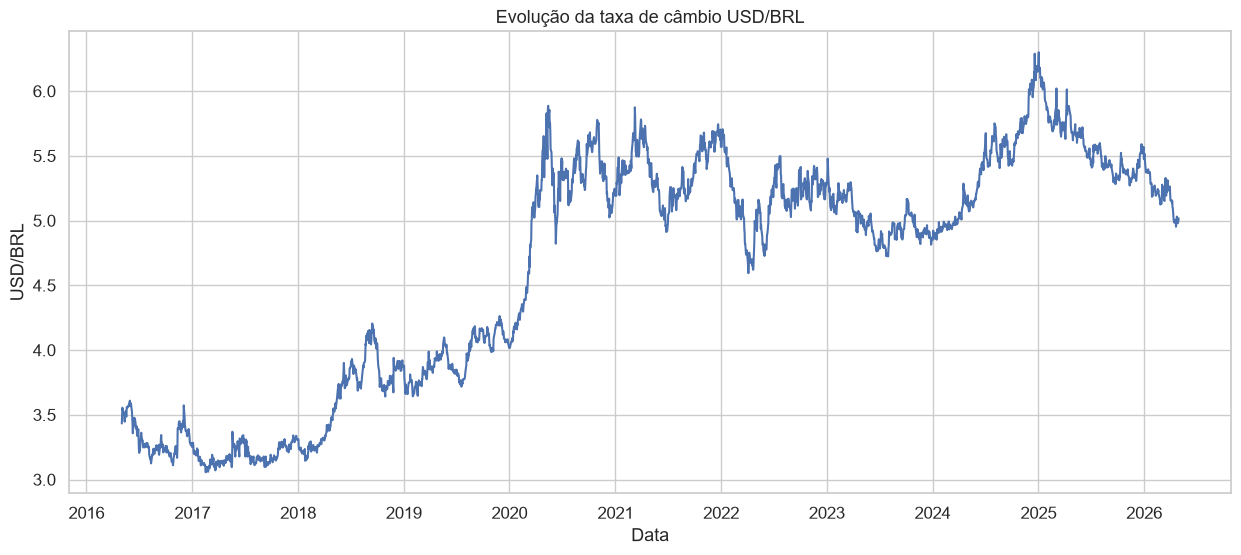

In [289]:
plt.figure(figsize=(15, 6))

plt.plot(df.index, df["USD/BRL"])

plt.title("Evolução da taxa de câmbio USD/BRL")
plt.xlabel("Data")
plt.ylabel("USD/BRL")

plt.show()

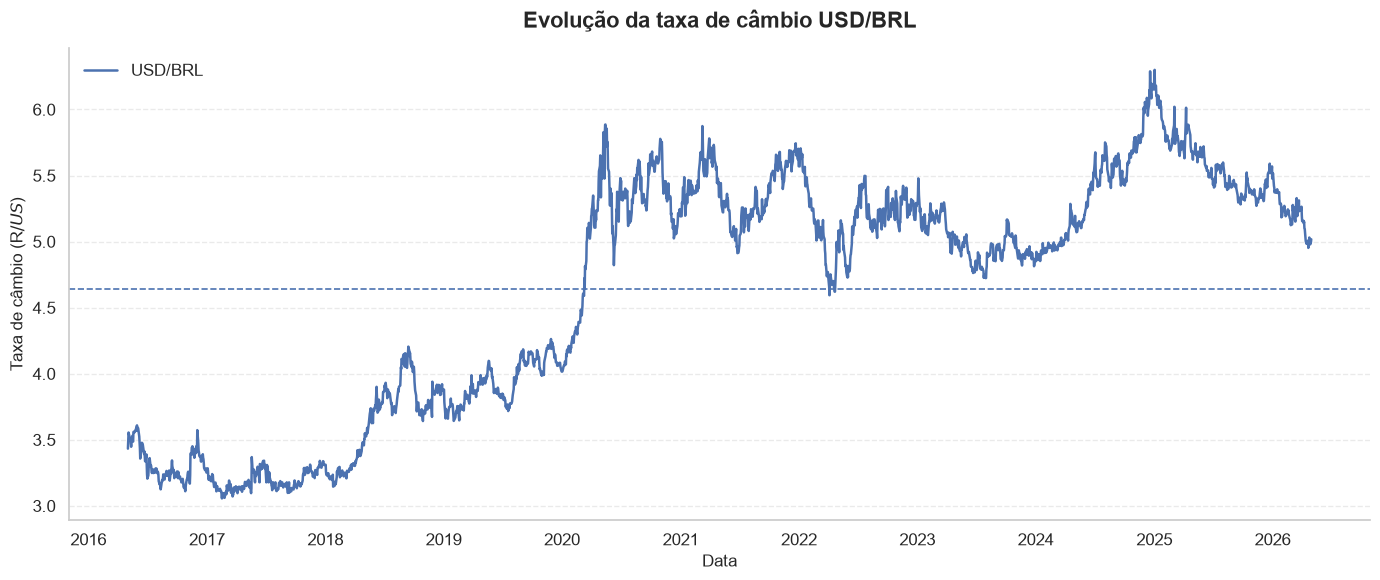

In [290]:


# Configuração do estilo
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1
)

# Figura
fig, ax = plt.subplots(figsize=(14, 6))

# Linha do câmbio
ax.plot(
    df.index,
    df["USD/BRL"],
    linewidth=1.8,
    label="USD/BRL"
)

# Título e rótulos
ax.set_title(
    "Evolução da taxa de câmbio USD/BRL",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("Taxa de câmbio (R$/US$)", fontsize=12)

# Formatação das datas
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Grade
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.grid(axis="x", visible=False)

# Remove bordas desnecessárias
sns.despine(
    ax=ax,
    top=True,
    right=True
)

# Legenda
ax.legend(
    frameon=False,
    loc="upper left"
)

media = df["USD/BRL"].mean()

ax.axhline(
    media,
    linestyle="--",
    linewidth=1.2,
    label=f"Média: R$/US$ {media:.2f}"
)
# Ajuste automático
plt.tight_layout()

# Alta resolução para o TCC
plt.savefig(
    f"{PATH_TO_SAVE}/graficos/evolucao_usd_brl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Pergunte:

Existem tendências?
Existem períodos de alta volatilidade?
Existem mudanças estruturais?
Existem períodos de valorização/desvalorização do real?

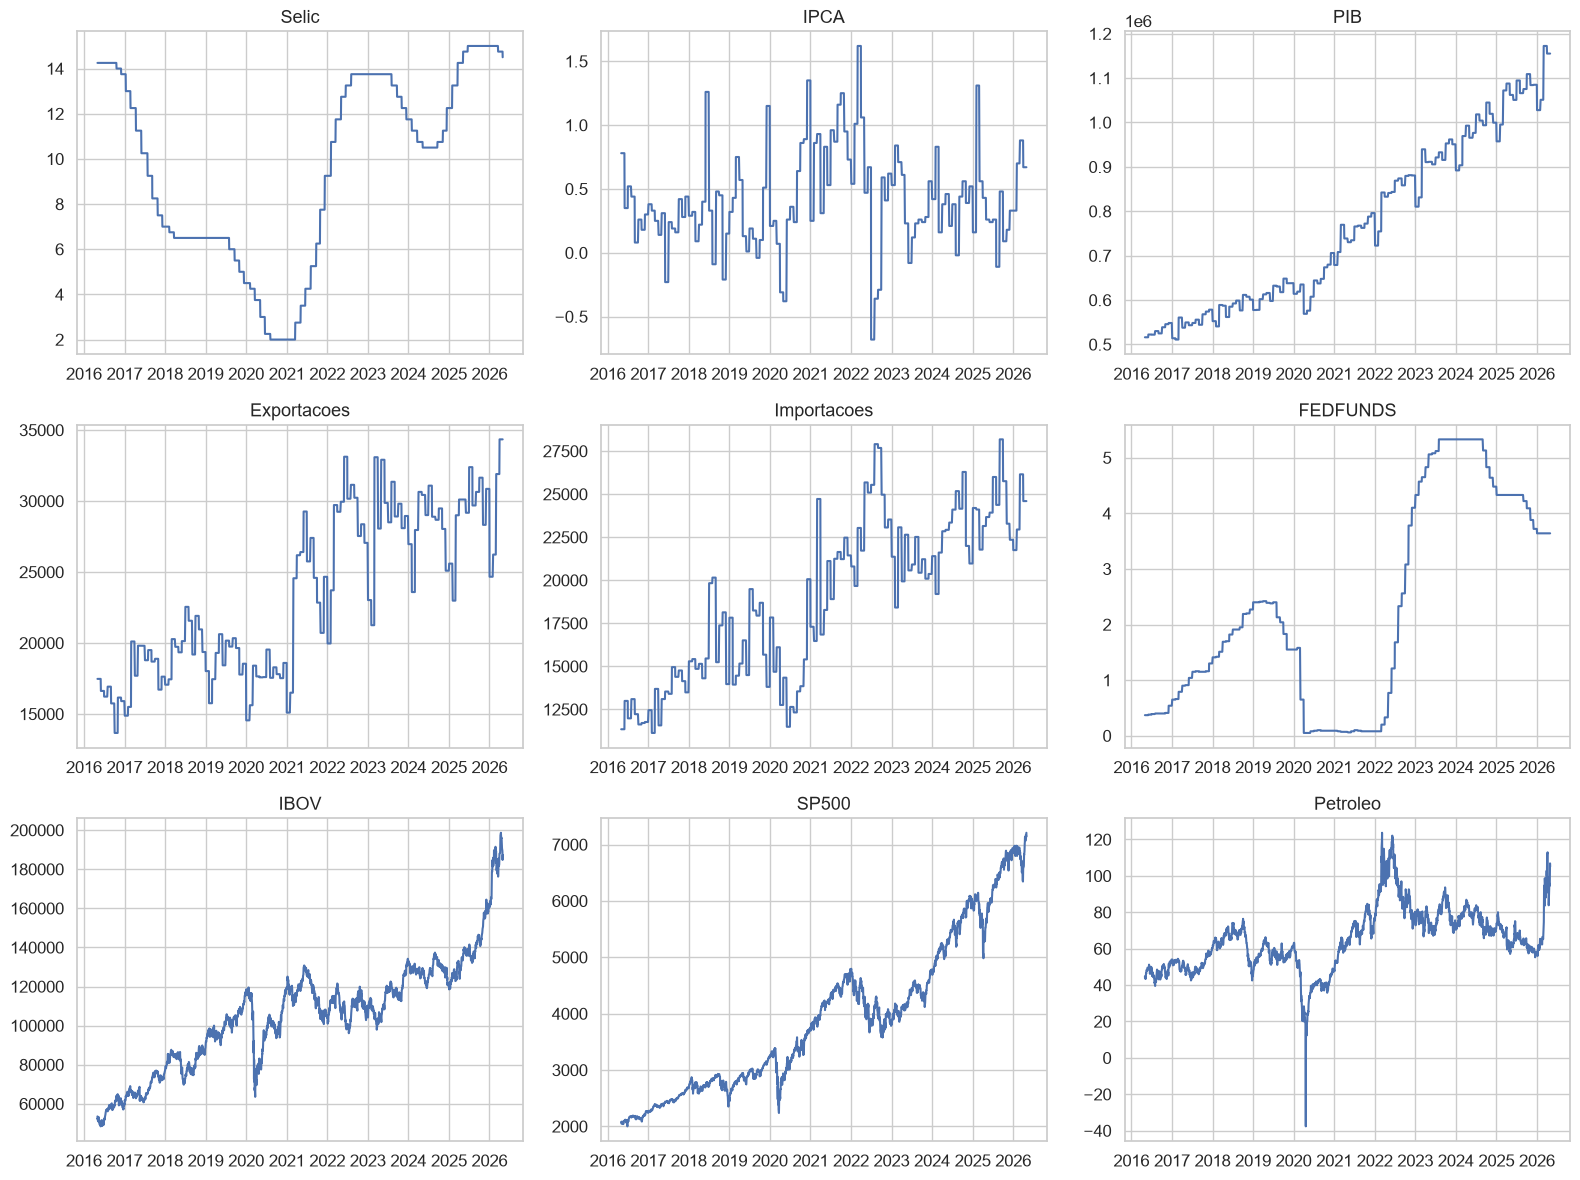

In [291]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

colunas = df.columns.tolist()
for ax, coluna in zip(axes.flat, colunas):
    ax.plot(df.index, df[coluna])
    ax.set_title(coluna)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [292]:
df_long = df.reset_index().melt(
    id_vars=df.index.name,
    var_name="Variavel",
    value_name="Valor"
)

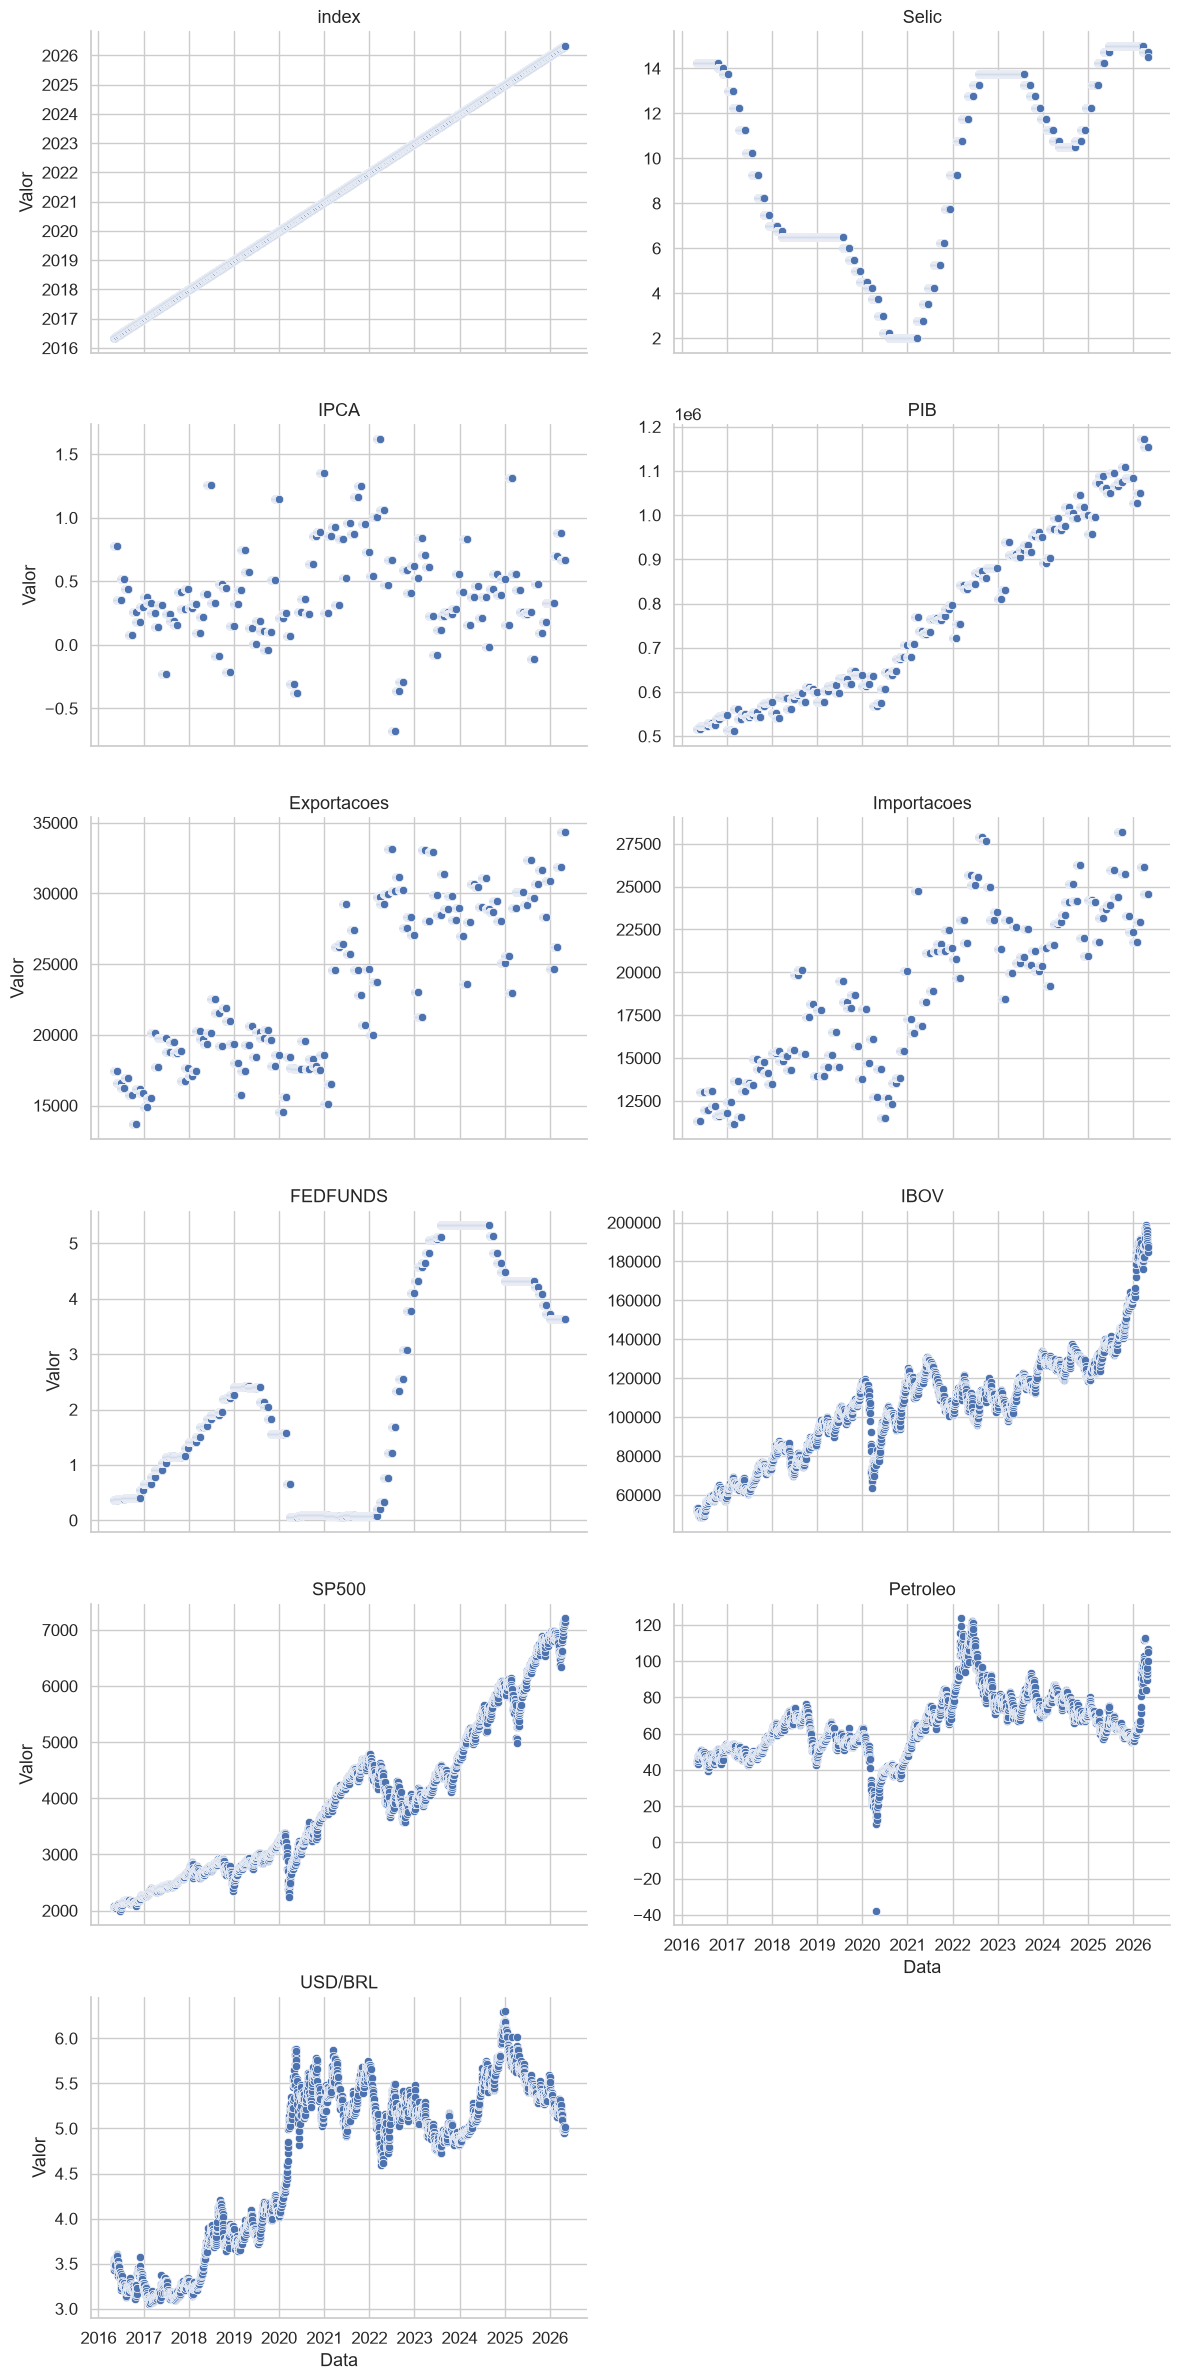

In [293]:
g = sns.FacetGrid(
    df_long,
    col="Variavel",
    col_wrap=2,
    height=4,
    aspect=1.5,
    sharex=True,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x=df.index,
    y="Valor"
)

g.set_axis_labels("Data", "Valor")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

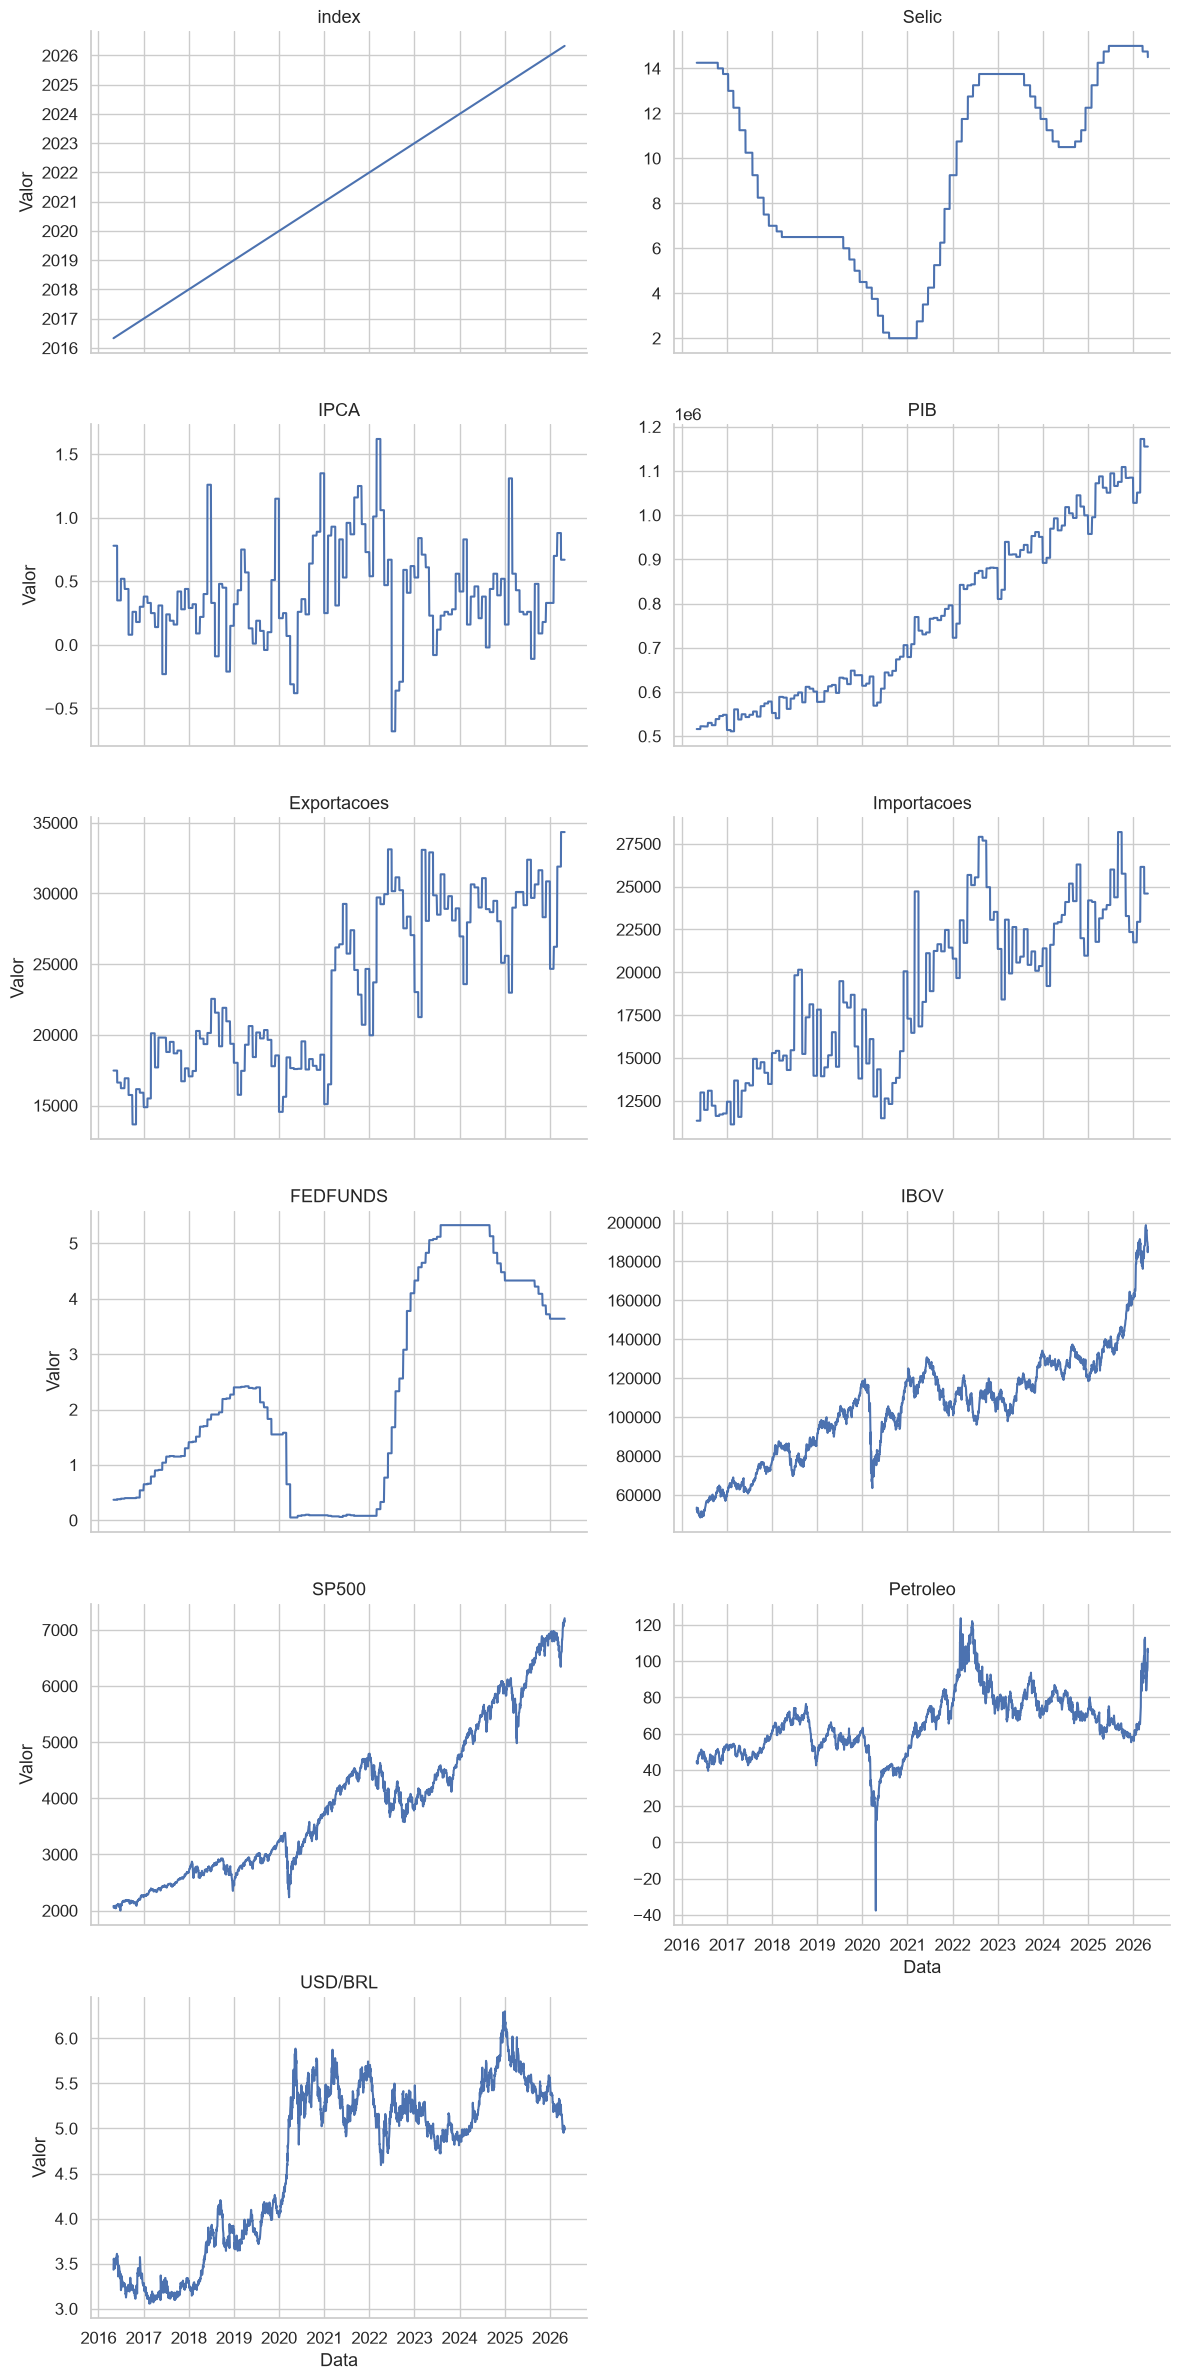

In [294]:
g = sns.FacetGrid(
    df_long,
    col="Variavel",
    col_wrap=2,
    height=4,
    aspect=1.5,
    sharex=True,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x=df.index,
    y="Valor"
)

g.set_axis_labels("Data", "Valor")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

# 7. Correlação

In [295]:
corr = df.corr(numeric_only=True)

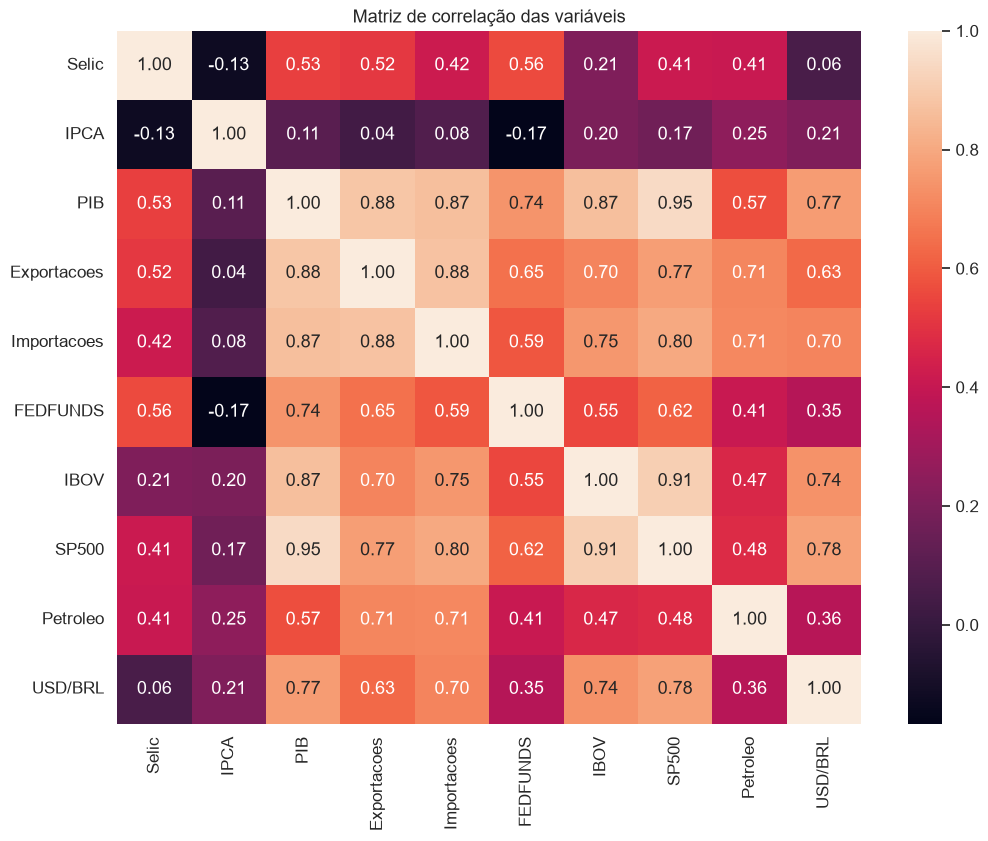

In [296]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlação das variáveis")

plt.show()

In [297]:
corr["USD/BRL"].sort_values(
    ascending=False
)

USD/BRL        1.000000
SP500          0.778540
PIB            0.767574
IBOV           0.736310
Importacoes    0.702404
Exportacoes    0.634093
Petroleo       0.361523
FEDFUNDS       0.352933
IPCA           0.210632
Selic          0.057016
Name: USD/BRL, dtype: float64

Isso permite discutir:

Quais variáveis apresentam maior associação linear com o câmbio?

## 7.1 Correlacao defasada

In [298]:
# for coluna in colunas:
#     df[f"{coluna}_lag1"] = df[coluna].shift(1)

In [299]:
# lag_corr = df.corr(numeric_only=True)["USD/BRL"]

In [300]:
# for coluna in colunas:
#     corr_lag = df["USD/BRL"].corr(
#         df[coluna].shift(1)
#     )

#     print(coluna, corr_lag)

In [301]:
# df

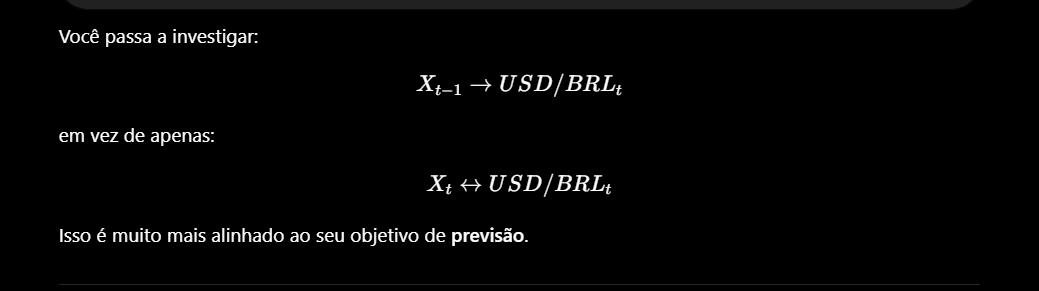

# 8. Relações USD/BRL × Variáveis

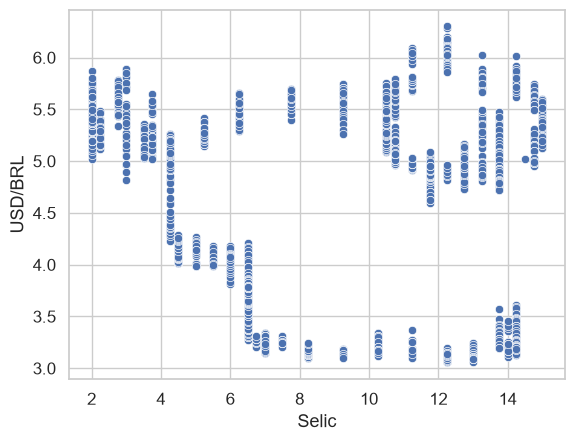

In [302]:
sns.scatterplot(
    data=df,
    x="Selic",
    y="USD/BRL"
)

plt.show()

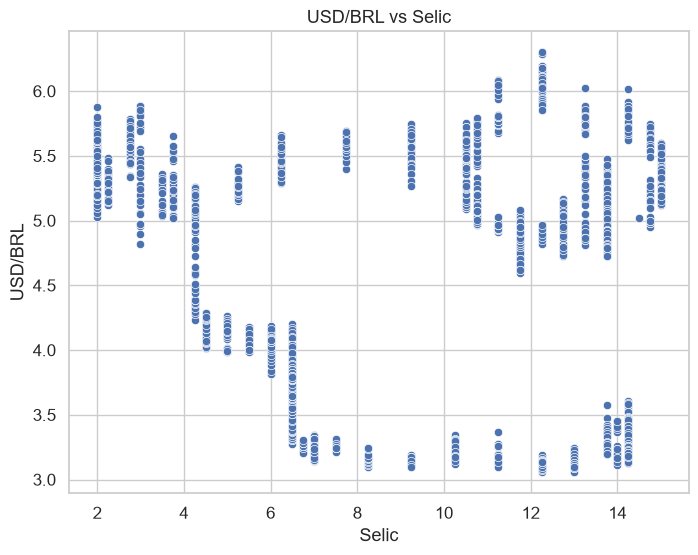

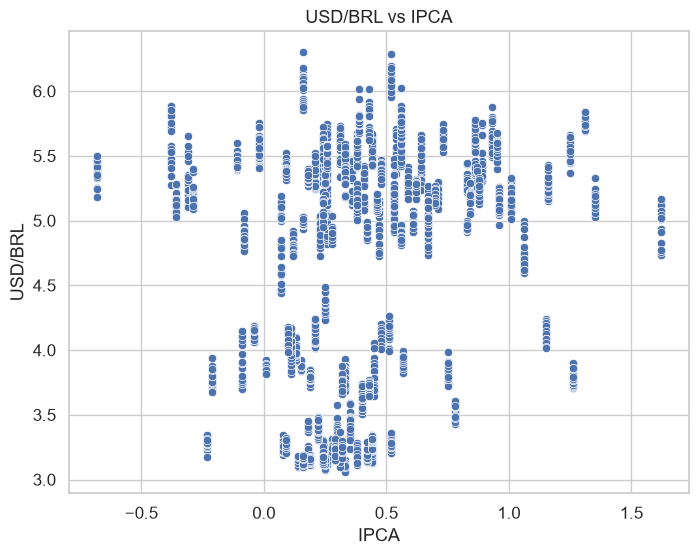

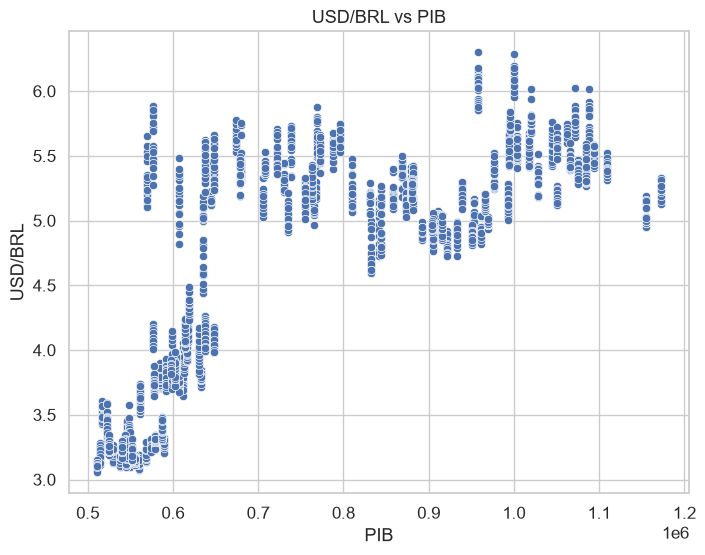

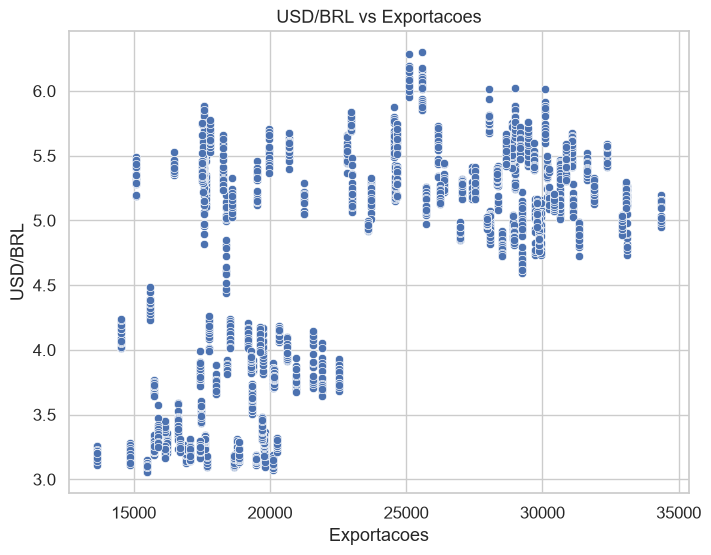

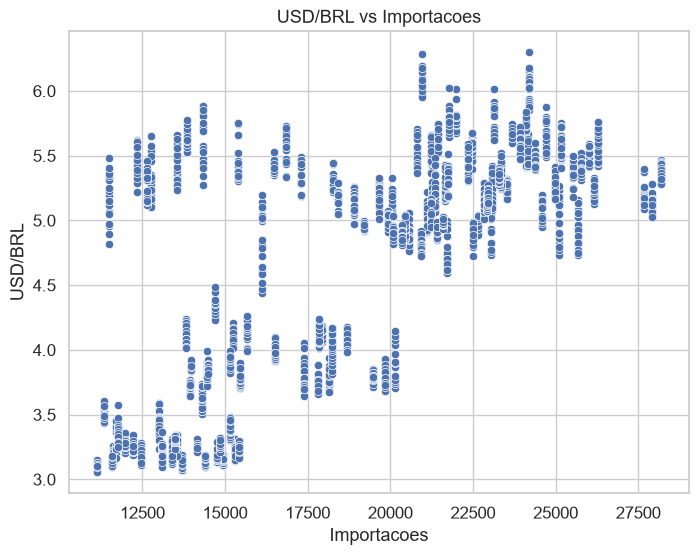

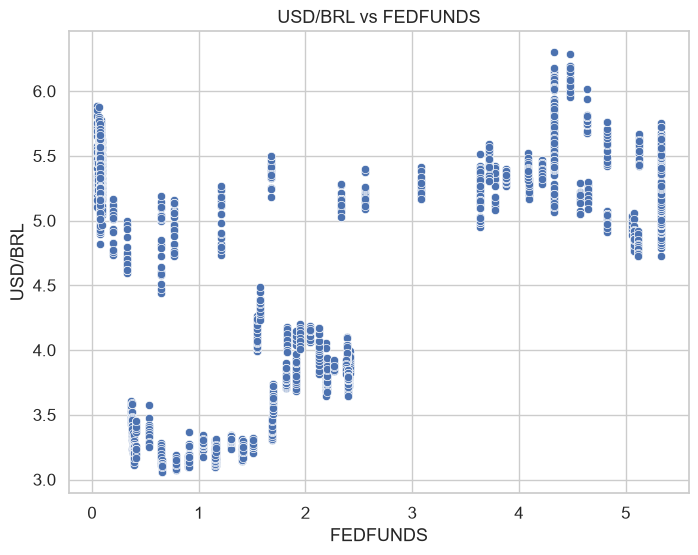

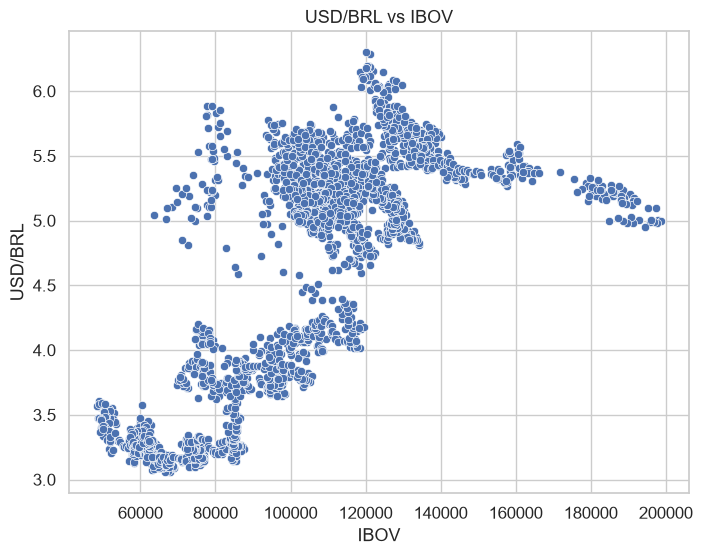

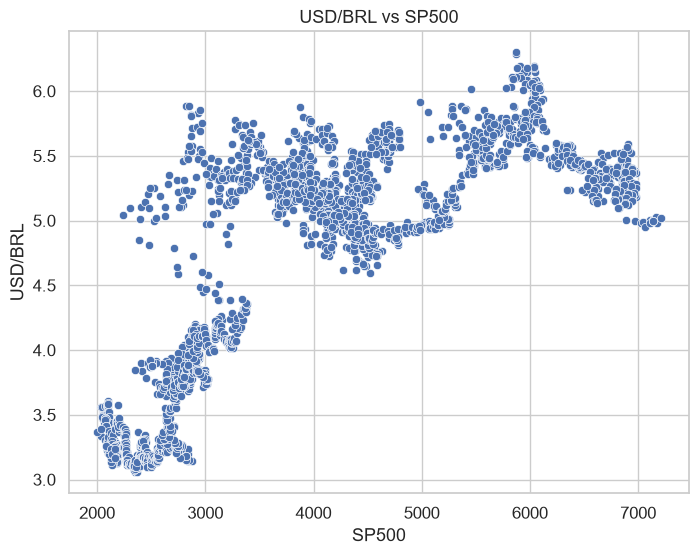

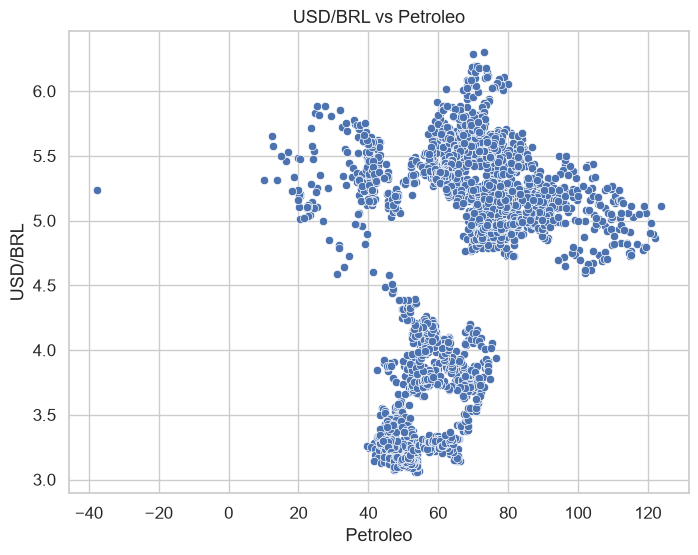

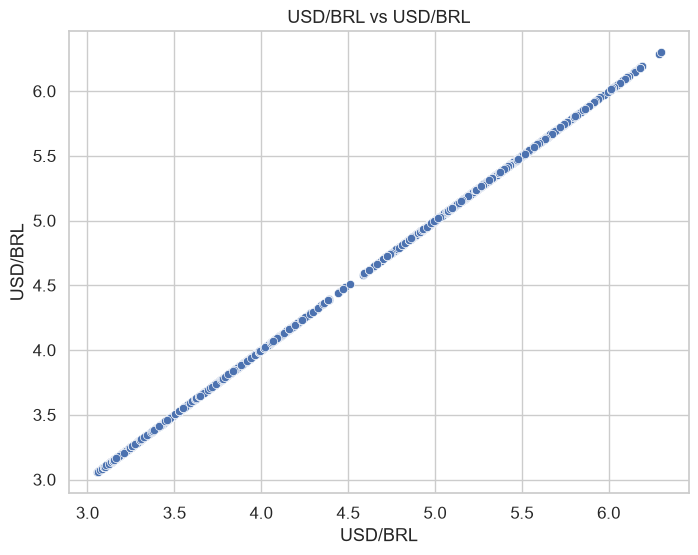

In [303]:
for coluna in colunas:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df,
        x=coluna,
        y="USD/BRL"
    )
    plt.title(f"USD/BRL vs {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("USD/BRL")
    plt.show()

# 9. Analisar multicolinearidade

<Axes: >

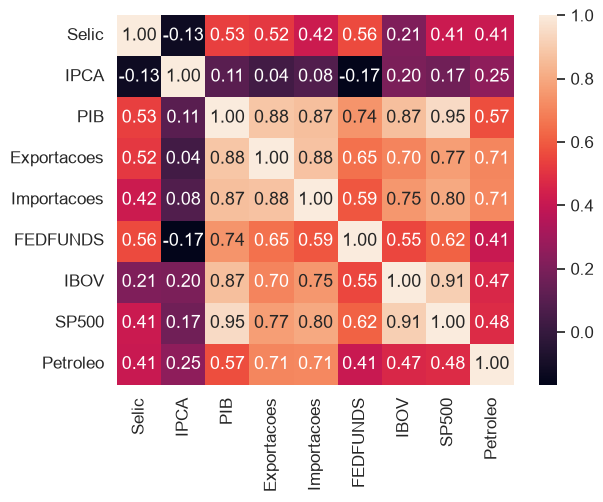

In [304]:
sns.heatmap(
    df.drop(columns="USD/BRL").corr(),
    annot=True,
    fmt=".2f"
)

In [305]:
if not base_c_nulos:
    X = df.drop(columns="USD/BRL").dropna()

    vif = pd.DataFrame()

    vif["Variável"] = X.columns

    vif["VIF"] = [
        variance_inflation_factor(
            X.values,
            i
        )
        for i in range(X.shape[1])
    ]

    vif

# 10. Analisar estacionariedade

In [306]:
resultado = adfuller(
    df["USD/BRL"].dropna()
)

print("ADF:", resultado[0])
print("p-value:", resultado[1])

ADF: -1.5155948785338489
p-value: 0.525783154740057


C:\Users\gnlin\AppData\Local\Temp\ipykernel_19196\2831788460.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


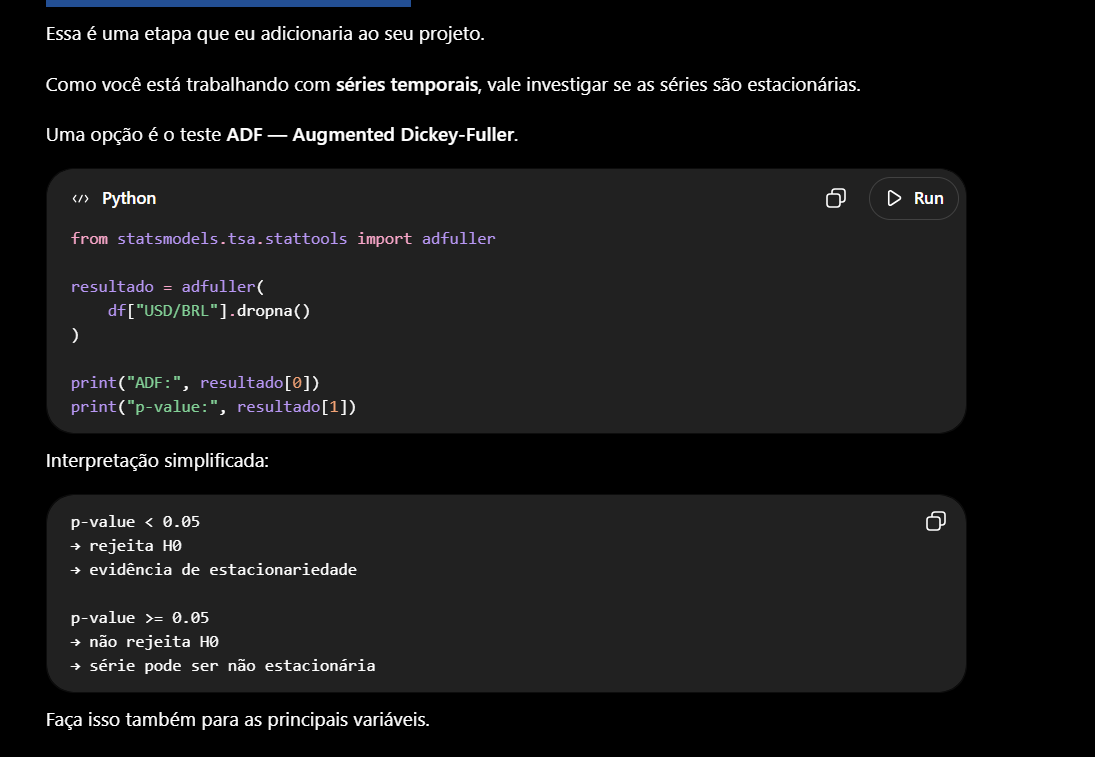

# 10. Se houver não estacionariedade: investigar retornos

In [307]:
df["USD_ret"] = np.log(
    df["USD/BRL"] /
    df["USD/BRL"].shift(1)
)

In [308]:
df["IBOV_ret"] = np.log(
    df["IBOV"] /
    df["IBOV"].shift(1)
)

In [309]:
df["SP500_ret"] = np.log(
    df["SP500"] /
    df["SP500"].shift(1)
)